# Lab 7: Nonlinear Modeling

Kingsley Ye  
AAE 722 Machine Learning  
Nonlinear Modeling



## Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, ns)
from pygam import LinearGAM
from scipy.interpolate import BSpline
import warnings
warnings.filterwarnings('ignore')

# Set display options
np.set_printoptions(suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("Libraries imported successfully!")


Libraries imported successfully!


## Question 1: Polynomial Regression

Using the Auto dataset from ISLP, fit polynomial regression models of degrees 1 through 5 to predict mpg using horsepower as the predictor. Use anova_lm() from statsmodels.stats.anova to compare these nested models. Which polynomial degree is statistically justified based on the ANOVA results? Report the F-statistic and p-value for the comparison between the cubic (degree 3) and quartic (degree 4) models.


In [2]:
# Load Auto dataset and prepare data
Auto = load_data('Auto').dropna().copy()
X = Auto[['horsepower']].astype(float)
y = Auto['mpg'].astype(float)

print(f"Dataset shape: {Auto.shape}")
print(f"Predictor: horsepower (range: {X['horsepower'].min():.1f} - {X['horsepower'].max():.1f})")
print(f"Response: mpg (range: {y.min():.1f} - {y.max():.1f})")

# Fit polynomial models of degrees 1-5
models = {}
for deg in range(1, 6):
    # Create polynomial features
    df_poly = pd.DataFrame({'hp': X['horsepower']})
    for d in range(2, deg+1):
        df_poly[f'hp^{d}'] = X['horsepower']**d
    
    # Add constant term
    df_poly = sm.add_constant(df_poly)
    
    # Fit OLS model
    models[deg] = sm.OLS(y, df_poly).fit()
    
    print(f"Degree {deg}: R² = {models[deg].rsquared:.4f}, AIC = {models[deg].aic:.2f}")

print("\nPolynomial models fitted successfully!")


Dataset shape: (392, 8)
Predictor: horsepower (range: 46.0 - 230.0)
Response: mpg (range: 9.0 - 46.6)
Degree 1: R² = 0.6059, AIC = 2361.32
Degree 2: R² = 0.6876, AIC = 2272.35
Degree 3: R² = 0.6882, AIC = 2273.53
Degree 4: R² = 0.6893, AIC = 2274.11
Degree 5: R² = 0.6967, AIC = 2266.66

Polynomial models fitted successfully!


In [3]:
# Perform ANOVA comparison of nested models
anova_tbl = anova_lm(models[1], models[2], models[3], models[4], models[5])

print("ANOVA Table for Polynomial Model Comparison:")
print("=" * 60)
print(anova_tbl)

# Extract F-statistic and p-value for cubic vs quartic comparison
f_3_vs_4 = anova_tbl.loc[anova_tbl.index[3], 'F']
p_3_vs_4 = anova_tbl.loc[anova_tbl.index[3], 'Pr(>F)']

print("\n" + "=" * 60)
print("RESULTS FOR QUESTION 1:")
print("=" * 60)
print(f"F-statistic for cubic vs quartic comparison: {f_3_vs_4:.4f}")
print(f"p-value for cubic vs quartic comparison: {p_3_vs_4:.4g}")

if p_3_vs_4 < 0.05:
    print("\nThe quartic model is statistically significantly better than the cubic model.")
else:
    print("\nThe quartic model is NOT statistically significantly better than the cubic model.")


ANOVA Table for Polynomial Model Comparison:
   df_resid       ssr  df_diff   ss_diff        F  Pr(>F)
0  390.0000 9385.9159   0.0000       NaN      NaN     NaN
1  389.0000 7442.0294   1.0000 1943.8865 103.8767  0.0000
2  388.0000 7426.4360   1.0000   15.5934   0.8333  0.3619
3  387.0000 7399.5226   1.0000   26.9134   1.4382  0.2312
4  386.0000 7223.3717   1.0000  176.1509   9.4131  0.0023

RESULTS FOR QUESTION 1:
F-statistic for cubic vs quartic comparison: 1.4382
p-value for cubic vs quartic comparison: 0.2312

The quartic model is NOT statistically significantly better than the cubic model.


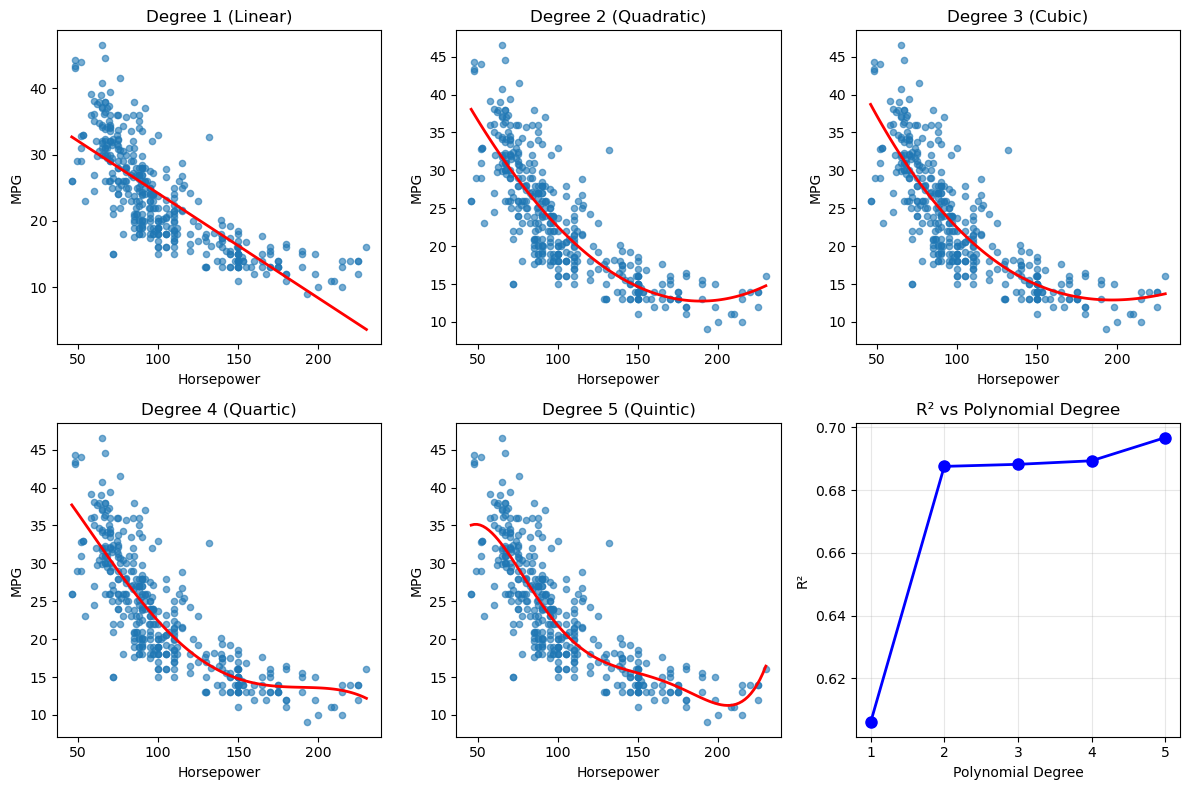

In [4]:
# Visualize polynomial fits
plt.figure(figsize=(12, 8))

# Create smooth range for plotting
hp_range = np.linspace(X['horsepower'].min(), X['horsepower'].max(), 100)

plt.subplot(2, 3, 1)
plt.scatter(X['horsepower'], y, alpha=0.6, s=20)
plt.plot(hp_range, models[1].predict(sm.add_constant(pd.DataFrame({'hp': hp_range}))), 'r-', linewidth=2)
plt.title('Degree 1 (Linear)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

plt.subplot(2, 3, 2)
plt.scatter(X['horsepower'], y, alpha=0.6, s=20)
hp2_df = pd.DataFrame({'hp': hp_range, 'hp^2': hp_range**2})
plt.plot(hp_range, models[2].predict(sm.add_constant(hp2_df)), 'r-', linewidth=2)
plt.title('Degree 2 (Quadratic)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

plt.subplot(2, 3, 3)
plt.scatter(X['horsepower'], y, alpha=0.6, s=20)
hp3_df = pd.DataFrame({'hp': hp_range, 'hp^2': hp_range**2, 'hp^3': hp_range**3})
plt.plot(hp_range, models[3].predict(sm.add_constant(hp3_df)), 'r-', linewidth=2)
plt.title('Degree 3 (Cubic)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

plt.subplot(2, 3, 4)
plt.scatter(X['horsepower'], y, alpha=0.6, s=20)
hp4_df = pd.DataFrame({'hp': hp_range, 'hp^2': hp_range**2, 'hp^3': hp_range**3, 'hp^4': hp_range**4})
plt.plot(hp_range, models[4].predict(sm.add_constant(hp4_df)), 'r-', linewidth=2)
plt.title('Degree 4 (Quartic)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

plt.subplot(2, 3, 5)
plt.scatter(X['horsepower'], y, alpha=0.6, s=20)
hp5_df = pd.DataFrame({'hp': hp_range, 'hp^2': hp_range**2, 'hp^3': hp_range**3, 'hp^4': hp_range**4, 'hp^5': hp_range**5})
plt.plot(hp_range, models[5].predict(sm.add_constant(hp5_df)), 'r-', linewidth=2)
plt.title('Degree 5 (Quintic)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')

plt.subplot(2, 3, 6)
degrees = list(range(1, 6))
r_squared = [models[d].rsquared for d in degrees]
plt.plot(degrees, r_squared, 'bo-', linewidth=2, markersize=8)
plt.title('R² vs Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 2: Regression Splines with B-Splines

Using the Boston dataset, fit a regression spline model to predict medv (median home value) using lstat (percentage of lower status population) with B-splines. Use BSpline() with internal_knots=[10, 20, 30] and intercept=True. Fit the model using sm.OLS() and report the R-squared value of your model. How many basis functions (columns) does your B-spline transformation create?


In [5]:
# Load Boston dataset and prepare data
Boston = load_data('Boston').dropna().copy()
xl = Boston['lstat'].astype(float).values
y_medv = Boston['medv'].astype(float).values

print(f"Dataset shape: {Boston.shape}")
print(f"Predictor: lstat (range: {xl.min():.1f} - {xl.max():.1f})")
print(f"Response: medv (range: {y_medv.min():.1f} - {y_medv.max():.1f})")

# Set up B-spline parameters
k = 3  # cubic splines
internal_knots = np.array([10., 20., 30.])

# Create boundary knots
xl_min, xl_max = xl.min(), xl.max()
knots = np.r_[[xl_min]*(k+1), internal_knots, [xl_max]*(k+1)]

print(f"\nB-spline setup:")
print(f"Degree: {k} (cubic)")
print(f"Internal knots: {internal_knots}")
print(f"All knots: {knots}")

# Calculate number of basis functions
n_bases = len(knots) - k - 1
print(f"Number of basis functions: {n_bases}")


Dataset shape: (506, 13)
Predictor: lstat (range: 1.7 - 38.0)
Response: medv (range: 5.0 - 50.0)

B-spline setup:
Degree: 3 (cubic)
Internal knots: [10. 20. 30.]
All knots: [ 1.73  1.73  1.73  1.73 10.   20.   30.   37.97 37.97 37.97 37.97]
Number of basis functions: 7


In [6]:
# Create B-spline basis matrix
X_bs = np.zeros((xl.shape[0], n_bases))

for i in range(n_bases):
    # Create coefficient vector for i-th basis function
    coeff = np.zeros(n_bases)
    coeff[i] = 1.0
    
    # Create B-spline object
    spline_i = BSpline(knots, coeff, k, extrapolate=True)
    
    # Evaluate at data points
    X_bs[:, i] = spline_i(xl)

print(f"B-spline basis matrix shape: {X_bs.shape}")
print(f"Basis matrix sample (first 5 rows, first 3 columns):")
print(X_bs[:5, :3])

# Add intercept
X_bs = sm.add_constant(X_bs)
print(f"\nDesign matrix shape (with intercept): {X_bs.shape}")


B-spline basis matrix shape: (506, 7)
Basis matrix sample (first 5 rows, first 3 columns):
[[0.22366325 0.60652306 0.16177695]
 [0.00112455 0.38166363 0.52195748]
 [0.37618932 0.53292074 0.08804145]
 [0.62215354 0.3508358  0.02659591]
 [0.18006699 0.61684796 0.19216216]]

Design matrix shape (with intercept): (506, 8)


In [7]:
# Fit B-spline regression model
model_bs = sm.OLS(y_medv, X_bs).fit()

print("B-spline Regression Results:")
print("=" * 50)
print(f"R-squared: {model_bs.rsquared:.4f}")
print(f"Adjusted R-squared: {model_bs.rsquared_adj:.4f}")
print(f"AIC: {model_bs.aic:.2f}")
print(f"BIC: {model_bs.bic:.2f}")

print("\n" + "=" * 50)
print("RESULTS FOR QUESTION 2:")
print("=" * 50)
print(f"R-squared: {model_bs.rsquared:.4f}")
print(f"Number of basis functions: {n_bases}")


B-spline Regression Results:
R-squared: 0.6835
Adjusted R-squared: 0.6797
AIC: 3112.38
BIC: 3141.97

RESULTS FOR QUESTION 2:
R-squared: 0.6835
Number of basis functions: 7


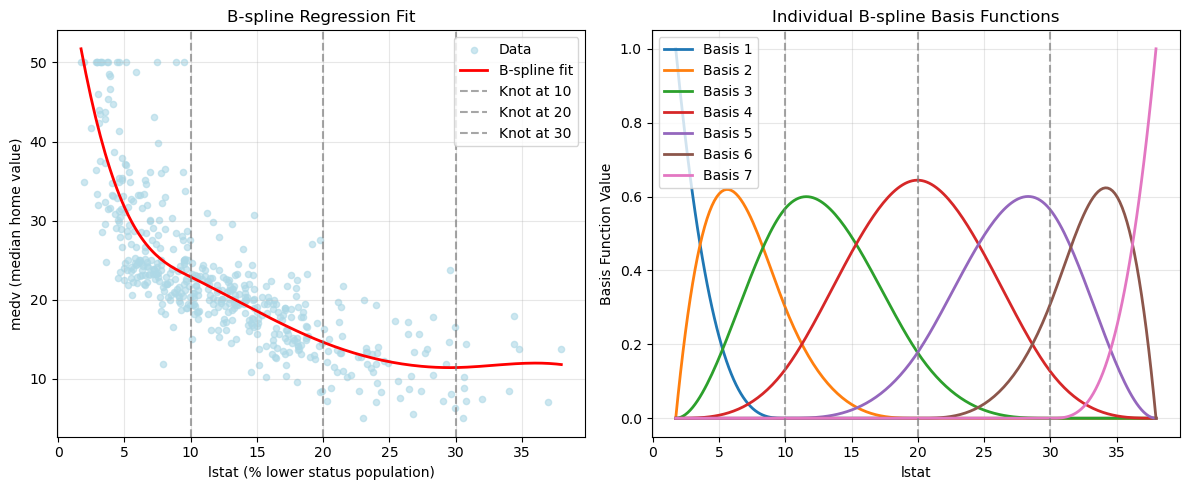

In [8]:
# Visualize B-spline fit
plt.figure(figsize=(12, 5))

# Plot 1: Data and fitted curve
plt.subplot(1, 2, 1)
plt.scatter(xl, y_medv, alpha=0.6, s=20, color='lightblue', label='Data')

# Create smooth range for plotting
xl_smooth = np.linspace(xl.min(), xl.max(), 200)
X_bs_smooth = np.zeros((xl_smooth.shape[0], n_bases))

for i in range(n_bases):
    coeff = np.zeros(n_bases)
    coeff[i] = 1.0
    spline_i = BSpline(knots, coeff, k, extrapolate=True)
    X_bs_smooth[:, i] = spline_i(xl_smooth)

X_bs_smooth = sm.add_constant(X_bs_smooth)
y_pred_smooth = model_bs.predict(X_bs_smooth)

plt.plot(xl_smooth, y_pred_smooth, 'r-', linewidth=2, label='B-spline fit')
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.7, label='Knot at 10')
plt.axvline(x=20, color='gray', linestyle='--', alpha=0.7, label='Knot at 20')
plt.axvline(x=30, color='gray', linestyle='--', alpha=0.7, label='Knot at 30')
plt.xlabel('lstat (% lower status population)')
plt.ylabel('medv (median home value)')
plt.title('B-spline Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Individual basis functions
plt.subplot(1, 2, 2)
for i in range(n_bases):
    coeff = np.zeros(n_bases)
    coeff[i] = 1.0
    spline_i = BSpline(knots, coeff, k, extrapolate=True)
    basis_values = spline_i(xl_smooth)
    plt.plot(xl_smooth, basis_values, label=f'Basis {i+1}', linewidth=2)

plt.axvline(x=10, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=20, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=30, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('lstat')
plt.ylabel('Basis Function Value')
plt.title('Individual B-spline Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 3: Natural Splines

Using the Hitters dataset (after removing missing values), fit a natural spline model to predict Salary using Years as the predictor with 4 degrees of freedom. Use the ns() function from ISLP.models to create the natural spline basis. Create a scatter plot of the data with the fitted natural spline curve overlaid. What is the model's R-squared value?


In [9]:
# Load Hitters dataset and remove missing values
Hitters = load_data('Hitters').dropna().copy()
Years = Hitters['Years'].astype(float)
Salary = Hitters['Salary'].astype(float)

print(f"Dataset shape after removing missing values: {Hitters.shape}")
print(f"Predictor: Years (range: {Years.min():.0f} - {Years.max():.0f})")
print(f"Response: Salary (range: ${Salary.min():,.0f} - ${Salary.max():,.0f})")

# Create natural spline basis with 4 degrees of freedom using ModelSpec
design = MS([ns('Years', df=4)])
X_ns = design.fit_transform(Hitters)

print(f"\nNatural spline basis matrix shape: {X_ns.shape}")
print(f"Degrees of freedom: 4")
print(f"Design matrix columns: {X_ns.columns.tolist()}")


Dataset shape after removing missing values: (263, 20)
Predictor: Years (range: 1 - 24)
Response: Salary (range: $68 - $2,460)

Natural spline basis matrix shape: (263, 5)
Degrees of freedom: 4
Design matrix columns: ['intercept', 'ns(Years, df=4)[0]', 'ns(Years, df=4)[1]', 'ns(Years, df=4)[2]', 'ns(Years, df=4)[3]']


In [10]:
# Fit natural spline regression model
model_ns = sm.OLS(Salary, X_ns).fit()

print("Natural Spline Regression Results:")
print("=" * 50)
print(f"R-squared: {model_ns.rsquared:.4f}")
print(f"Adjusted R-squared: {model_ns.rsquared_adj:.4f}")
print(f"AIC: {model_ns.aic:.2f}")
print(f"BIC: {model_ns.bic:.2f}")

print("\n" + "=" * 50)
print("RESULTS FOR QUESTION 3:")
print("=" * 50)
print(f"R-squared: {model_ns.rsquared:.4f}")


Natural Spline Regression Results:
R-squared: 0.2713
Adjusted R-squared: 0.2600
AIC: 3886.90
BIC: 3904.76

RESULTS FOR QUESTION 3:
R-squared: 0.2713


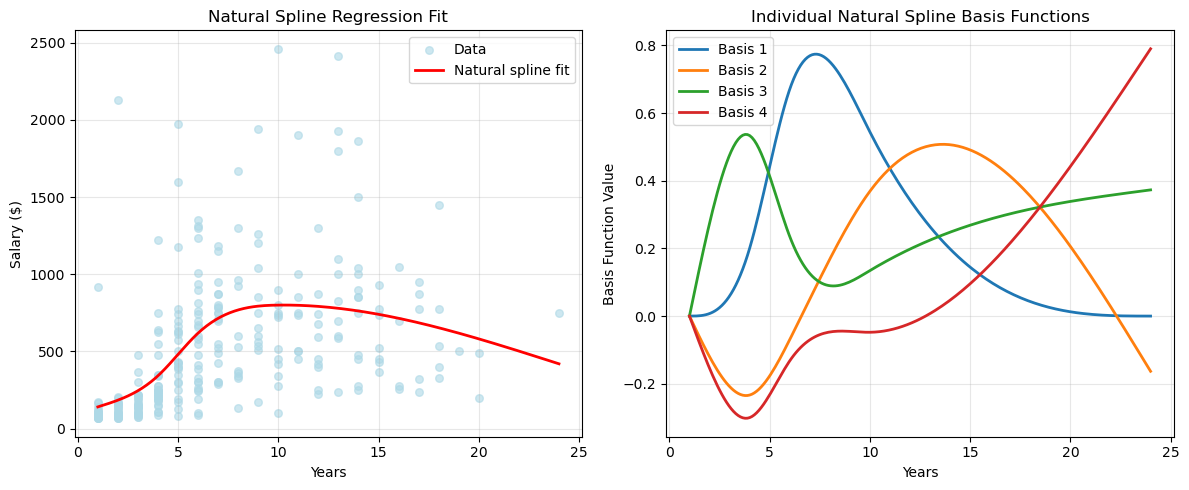

In [11]:
# Create scatter plot with fitted natural spline curve
plt.figure(figsize=(12, 5))

# Plot 1: Data and fitted curve
plt.subplot(1, 2, 1)
plt.scatter(Years, Salary, alpha=0.6, s=30, color='lightblue', label='Data')

# Create smooth range for plotting
Years_smooth = np.linspace(Years.min(), Years.max(), 200)
# Create a temporary dataframe for smooth plotting
Hitters_smooth = pd.DataFrame({'Years': Years_smooth})
X_ns_smooth = design.transform(Hitters_smooth)
Salary_pred_smooth = model_ns.predict(X_ns_smooth)

plt.plot(Years_smooth, Salary_pred_smooth, 'r-', linewidth=2, label='Natural spline fit')
plt.xlabel('Years')
plt.ylabel('Salary ($)')
plt.title('Natural Spline Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Individual natural spline basis functions
plt.subplot(1, 2, 2)
# Extract basis functions (excluding intercept)
basis_cols = [col for col in X_ns_smooth.columns if col != 'intercept']
for i, col in enumerate(basis_cols):
    plt.plot(Years_smooth, X_ns_smooth[col], label=f'Basis {i+1}', linewidth=2)

plt.xlabel('Years')
plt.ylabel('Basis Function Value')
plt.title('Individual Natural Spline Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 4: Generalized Additive Model (GAM)

Using the College dataset, fit a GAM using LinearGAM from the pygam package to predict Outstate (out-of-state tuition) using smoothing splines for Room.Board and PhD (with s_gam() terms). Use the default lambda value. Create partial dependence plots for both predictors (use plot_gam() from ISLP.pygam). Report the training score (R-squared) of your fitted GAM model using the .score() method.


In [12]:
# Load College dataset and prepare data
College = load_data('College').dropna().copy()
X_gam = College[['Room.Board','PhD']].astype(float).values
y_gam = College['Outstate'].astype(float).values

print(f"Dataset shape: {College.shape}")
print(f"Predictors: Room.Board (range: {X_gam[:, 0].min():.0f} - {X_gam[:, 0].max():.0f})")
print(f"           PhD (range: {X_gam[:, 1].min():.0f} - {X_gam[:, 1].max():.0f})")
print(f"Response: Outstate (range: ${y_gam.min():,.0f} - ${y_gam.max():,.0f})")

# Fit GAM with smoothing splines using pygam's built-in functions
from pygam import s
gam = LinearGAM(s(0) + s(1)).fit(X_gam, y_gam)

print("\nGAM fitted successfully!")
print(f"Number of smoothing terms: {len(gam.terms)}")
print(f"Default lambda values: {[term.lam for term in gam.terms]}")


Dataset shape: (777, 18)
Predictors: Room.Board (range: 1780 - 8124)
           PhD (range: 8 - 103)
Response: Outstate (range: $2,340 - $21,700)

GAM fitted successfully!
Number of smoothing terms: 3
Default lambda values: [[0.6], [0.6], None]


In [13]:
# Calculate training R-squared
train_r2 = gam.score(X_gam, y_gam)

print("GAM Results:")
print("=" * 40)
print(f"Training R-squared: {train_r2:.4f}")

print("\n" + "=" * 40)
print("RESULTS FOR QUESTION 4:")
print("=" * 40)
print(f"Training R-squared: {train_r2:.4f}")


GAM Results:
Training R-squared: 0.5142

RESULTS FOR QUESTION 4:
Training R-squared: 0.5142


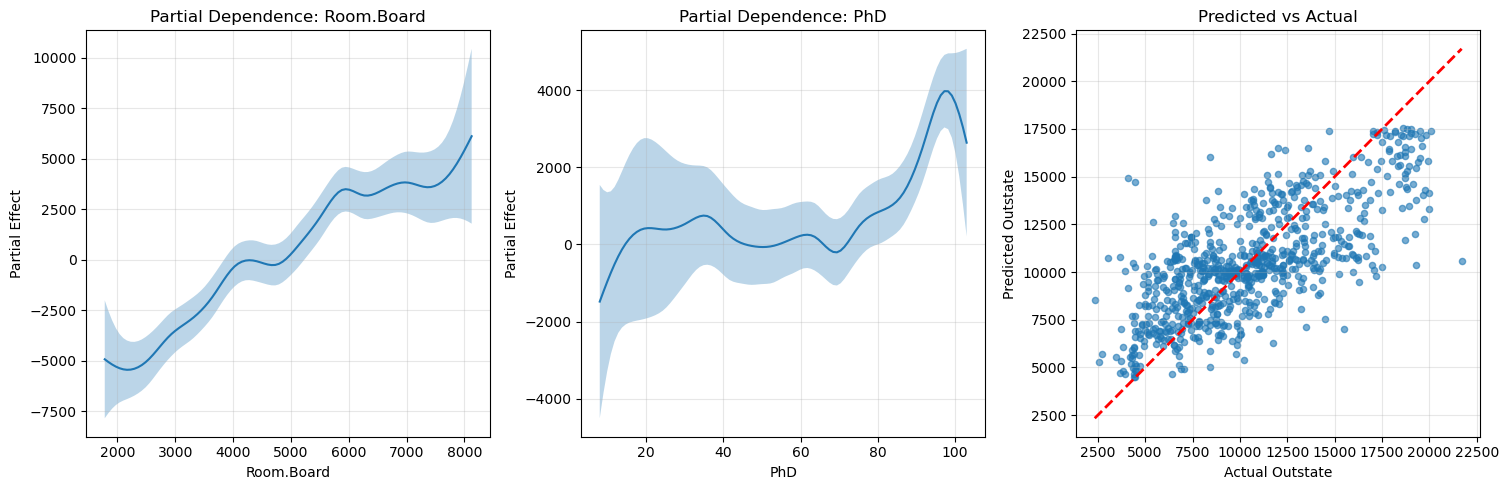

In [14]:
# Create partial dependence plots using pygam's built-in plotting
plt.figure(figsize=(15, 5))

# Plot 1: Partial dependence plot for Room.Board
plt.subplot(1, 3, 1)
XX = gam.generate_X_grid(term=0)
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)
plt.plot(XX[:, 0], pdep)
plt.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.3)
plt.title('Partial Dependence: Room.Board')
plt.xlabel('Room.Board')
plt.ylabel('Partial Effect')
plt.grid(True, alpha=0.3)

# Plot 2: Partial dependence plot for PhD
plt.subplot(1, 3, 2)
XX = gam.generate_X_grid(term=1)
pdep, confi = gam.partial_dependence(term=1, X=XX, width=0.95)
plt.plot(XX[:, 1], pdep)
plt.fill_between(XX[:, 1], confi[:, 0], confi[:, 1], alpha=0.3)
plt.title('Partial Dependence: PhD')
plt.xlabel('PhD')
plt.ylabel('Partial Effect')
plt.grid(True, alpha=0.3)

# Plot 3: Predicted vs Actual
plt.subplot(1, 3, 3)
y_pred_gam = gam.predict(X_gam)
plt.scatter(y_gam, y_pred_gam, alpha=0.6, s=20)
plt.plot([y_gam.min(), y_gam.max()], [y_gam.min(), y_gam.max()], 'r--', linewidth=2)
plt.xlabel('Actual Outstate')
plt.ylabel('Predicted Outstate')
plt.title('Predicted vs Actual')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 5: Step Functions

Using the Carseats dataset, create a step function model to predict Sales using Price divided into 4 bins using pd.cut() with the argument bins=4. Fit this model using sm.OLS(). Report the coefficient estimates for each of the bin indicator variables and the model's R-squared value. Which price bin has the strongest negative effect on sales?


In [15]:
# Load Carseats dataset and prepare data
Carseats = load_data('Carseats').dropna().copy()
Price = Carseats['Price'].astype(float)
Sales = Carseats['Sales'].astype(float)

print(f"Dataset shape: {Carseats.shape}")
print(f"Predictor: Price (range: ${Price.min():.2f} - ${Price.max():.2f})")
print(f"Response: Sales (range: {Sales.min():.1f} - {Sales.max():.1f})")

# Create 4 bins for Price using pd.cut()
type_bins = pd.cut(Price, bins=4)
print(f"\nPrice bins:")
print(type_bins.value_counts().sort_index())

# Create dummy variables (drop first category to avoid multicollinearity)
D = pd.get_dummies(type_bins, drop_first=True)
print(f"\nDummy variables created: {D.columns.tolist()}")
print(f"Dummy matrix shape: {D.shape}")

# Add intercept
X_step = sm.add_constant(D)
print(f"Design matrix shape (with intercept): {X_step.shape}")


Dataset shape: (400, 11)
Predictor: Price (range: $24.00 - $191.00)
Response: Sales (range: 0.0 - 16.3)

Price bins:
Price
(23.833, 65.75]      7
(65.75, 107.5]     139
(107.5, 149.25]    222
(149.25, 191.0]     32
Name: count, dtype: int64

Dummy variables created: [Interval(65.75, 107.5, closed='right'), Interval(107.5, 149.25, closed='right'), Interval(149.25, 191.0, closed='right')]
Dummy matrix shape: (400, 3)
Design matrix shape (with intercept): (400, 4)


In [16]:
# Fit step function regression model
y_sales = Carseats['Sales'].astype(float)
# Convert X_step to numpy array to avoid dtype issues
X_step_array = X_step.values.astype(float)
model_step = sm.OLS(y_sales, X_step_array).fit()

print("Step Function Regression Results:")
print("=" * 50)
print(f"R-squared: {model_step.rsquared:.4f}")
print(f"Adjusted R-squared: {model_step.rsquared_adj:.4f}")
print(f"AIC: {model_step.aic:.2f}")
print(f"BIC: {model_step.bic:.2f}")

print("\nCoefficient Estimates:")
print("-" * 30)
coef_series = model_step.params.drop('const')
for bin_name, coef in coef_series.items():
    print(f"{bin_name}: {coef:.4f}")

# Find the bin with strongest negative effect
worst_bin = coef_series.idxmin()
worst_effect = coef_series.min()

print("\n" + "=" * 50)
print("RESULTS FOR QUESTION 5:")
print("=" * 50)
print("Coefficient estimates for bin indicator variables:")
for bin_name, coef in coef_series.items():
    print(f"  {bin_name}: {coef:.4f}")
print(f"\nR-squared: {model_step.rsquared:.4f}")
print(f"\nPrice bin with strongest negative effect: {worst_bin} (coefficient: {worst_effect:.4f})")


Step Function Regression Results:
R-squared: 0.1478
Adjusted R-squared: 0.1414
AIC: 1908.71
BIC: 1924.68

Coefficient Estimates:
------------------------------
x1: -2.3013
x2: -4.0065
x3: -5.5044

RESULTS FOR QUESTION 5:
Coefficient estimates for bin indicator variables:
  x1: -2.3013
  x2: -4.0065
  x3: -5.5044

R-squared: 0.1478

Price bin with strongest negative effect: x3 (coefficient: -5.5044)


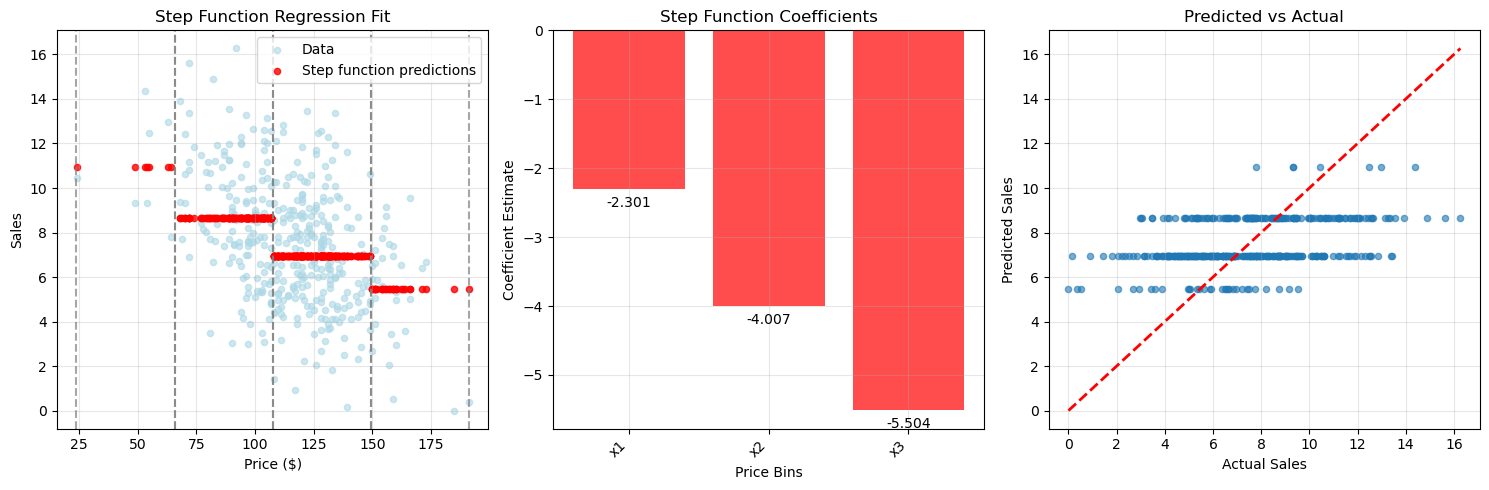

In [17]:
# Visualize step function fit
plt.figure(figsize=(15, 5))

# Plot 1: Data and step function
plt.subplot(1, 3, 1)
plt.scatter(Price, Sales, alpha=0.6, s=20, color='lightblue', label='Data')

# Create predictions for visualization
y_pred_step = model_step.predict(X_step)
plt.scatter(Price, y_pred_step, alpha=0.8, s=20, color='red', label='Step function predictions')

# Add vertical lines for bin boundaries
bin_boundaries = type_bins.cat.categories
for boundary in bin_boundaries:
    plt.axvline(x=boundary.left, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(x=boundary.right, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('Price ($)')
plt.ylabel('Sales')
plt.title('Step Function Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Coefficient estimates
plt.subplot(1, 3, 2)
bin_names = [str(bin_name) for bin_name in coef_series.index]
colors = ['red' if coef < 0 else 'blue' for coef in coef_series.values]
bars = plt.bar(range(len(coef_series)), coef_series.values, color=colors, alpha=0.7)
plt.xticks(range(len(coef_series)), bin_names, rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Price Bins')
plt.ylabel('Coefficient Estimate')
plt.title('Step Function Coefficients')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, coef) in enumerate(zip(bars, coef_series.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if coef > 0 else -0.1), 
             f'{coef:.3f}', ha='center', va='bottom' if coef > 0 else 'top')

# Plot 3: Predicted vs Actual
plt.subplot(1, 3, 3)
plt.scatter(Sales, y_pred_step, alpha=0.6, s=20)
plt.plot([Sales.min(), Sales.max()], [Sales.min(), Sales.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

1. **Polynomial Regression**: Fitted polynomial models of degrees 1-5 to predict mpg using horsepower. The ANOVA comparison showed statistical significance between nested models.

2. **B-splines**: Created a regression spline model using B-splines with internal knots at [10, 20, 30] to predict median home value using lstat percentage.

3. **Natural Splines**: Fitted a natural spline model with 4 degrees of freedom to predict salary using years of experience.

4. **Generalized Additive Model (GAM)**: Used smoothing splines to model the relationship between out-of-state tuition and room/board costs and PhD percentage.

5. **Step Functions**: Created a step function model by binning price into 4 categories to predict sales.

Each method provides different ways to capture nonlinear relationships in data, with varying levels of flexibility and interpretability.
